# Vaccine Hesitancy Analysis Workflow  
**Study:** *Barriers to Childhood Immunizations: Vaccine Hesitancy among mothers with children under five years old in selected barangay in the Province of Rizal, Philippines*

This notebook is aligned with the manuscript's analysis plan:
- descriptive statistics, frequency distributions, tables, means, and standard deviations
- Cronbach's alpha for internal consistency
- Pearson correlation at **α = 0.05**
- visualizations for the four study constructs

## Important data note
The manuscript states that negatively worded items should be reverse-coded before computing final scores.  
This notebook **recomputes all scale scores from the item-level responses** and does **not** rely on the precomputed `Mean ...` columns in the CSV.

It also fixes a common `statsmodels/patsy` issue by renaming columns with spaces to safe snake_case names.

In [2]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import math
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')

In [3]:
# -------------------------------------------------------------------
# 1. FILE PATHS
# -------------------------------------------------------------------
# Update this path if your CSV is in a different folder.
DATA_PATH = Path('Dataset-Gomez-Et-al.csv')

# Folder where exported tables and figures will be saved
OUTPUT_DIR = Path('gomez_analysis_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)

print('Data path:', DATA_PATH.resolve())
print('Output folder:', OUTPUT_DIR.resolve())

Data path: /Users/freshliannes.rosal/Documents/Stat Client/Princess /Dataset-Gomez-Et-al.csv
Output folder: /Users/freshliannes.rosal/Documents/Stat Client/Princess /gomez_analysis_outputs


In [4]:
# -------------------------------------------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------------------------------------------
def clean_column_names(columns):
    """Convert column names to snake_case to avoid patsy/statsmodels formula errors."""
    return (
        pd.Index(columns)
        .str.strip()
        .str.lower()
        .str.replace('#', 'number', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace('(', '', regex=False)
        .str.replace(')', '', regex=False)
        .str.replace('-', '_', regex=False)
        .str.replace(' ', '_', regex=False)
    )

def cronbach_alpha(df_items):
    """Compute Cronbach's alpha from a DataFrame of item responses."""
    df_items = df_items.dropna(axis=0, how='any')
    k = df_items.shape[1]
    if k < 2:
        return np.nan
    item_variances = df_items.var(axis=0, ddof=1)
    total_scores = df_items.sum(axis=1)
    total_variance = total_scores.var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

def alpha_if_item_deleted(df_items):
    rows = []
    for col in df_items.columns:
        alpha_val = cronbach_alpha(df_items.drop(columns=[col]))
        rows.append({'item_deleted': col, 'alpha_if_deleted': alpha_val})
    return pd.DataFrame(rows).sort_values('alpha_if_deleted', ascending=False)

def corrected_item_total_correlation(df_items):
    rows = []
    for col in df_items.columns:
        total_without_item = df_items.drop(columns=[col]).sum(axis=1)
        r, p = stats.pearsonr(df_items[col], total_without_item)
        rows.append({'item': col, 'corrected_item_total_r': r, 'p_value': p})
    return pd.DataFrame(rows).sort_values('corrected_item_total_r', ascending=False)

def fisher_r_ci(r, n, alpha=0.05):
    if abs(r) >= 1 or n <= 3:
        return np.nan, np.nan
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha/2)
    lo, hi = z - z_crit * se, z + z_crit * se
    return np.tanh(lo), np.tanh(hi)

def interpret_r(r):
    a = abs(r)
    if a < 0.10:
        return 'negligible'
    elif a < 0.30:
        return 'weak'
    elif a < 0.50:
        return 'moderate'
    elif a < 0.70:
        return 'strong'
    else:
        return 'very strong'

def likert_interpretation(mean_score):
    if pd.isna(mean_score):
        return np.nan
    if mean_score < 1.81:
        return 'Strongly Disagree'
    elif mean_score < 2.61:
        return 'Disagree'
    elif mean_score < 3.41:
        return 'Neutral'
    elif mean_score < 4.21:
        return 'Agree'
    else:
        return 'Strongly Agree'

def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def save_df(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path

In [5]:
# -------------------------------------------------------------------
# 3. LOAD DATA
# -------------------------------------------------------------------
df_raw = pd.read_csv(DATA_PATH)
print('Raw shape:', df_raw.shape)
df_raw.head()

Raw shape: (999, 36)


,Respondent #,Date,PAB1,PAB2,PAB3,PAB4,PAB5,PAB6,PAB7,Mean PAB,Ordinal PAB,HSA1,HSA2,HSA3,HSA4,HSA5,HSA6,HSA7,Mean HSA,Ordinal HSA,IRS1,IRS2,IRS3,IRS4,IRS5,IRS6,IRS7,Mean IRS,Ordinal IRS,VH1,VH2,VH3,VH4,VH5,Mean VH,Ordinal VH
0,R01,02/08/2026,4.0,4.0,3.0,4.0,3.0,4.0,4.0,3.71,4.0,4.0,5.0,2.0,5.0,4.0,5.0,3.0,4.00,4.0,2.0,2.0,4.0,4.0,5.0,5.0,2.0,3.43,4.0,5.0,2.0,5.0,5.0,5.0,4.4,5.0
1,R02,02/08/2026,4.0,3.0,4.0,5.0,3.0,2.0,5.0,3.71,4.0,2.0,5.0,4.0,4.0,4.0,5.0,4.0,4.00,4.0,4.0,4.0,4.0,4.0,4.0,3.0,2.0,3.57,4.0,4.0,1.0,5.0,5.0,5.0,4.0,4.0
2,R03,02/08/2026,4.0,2.0,4.0,4.0,2.0,4.0,4.0,3.43,4.0,4.0,4.0,2.0,4.0,4.0,4.0,4.0,3.71,4.0,4.0,4.0,4.0,4.0,4.0,2.0,2.0,3.43,4.0,4.0,2.0,4.0,4.0,4.0,3.6,4.0
3,R04,02/08/2026,4.0,2.0,4.0,4.0,4.0,4.0,4.0,3.71,4.0,2.0,2.0,4.0,2.0,2.0,2.0,2.0,2.29,2.0,2.0,2.0,2.0,4.0,4.0,2.0,2.0,2.57,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,R05,02/08/2026,2.0,2.0,4.0,2.0,4.0,4.0,4.0,3.14,3.0,2.0,1.0,4.0,1.0,3.0,1.0,2.0,2.00,2.0,4.0,4.0,4.0,4.0,1.0,2.0,1.0,2.86,3.0,3.0,4.0,4.0,4.0,3.0,3.6,4.0


In [6]:
# Standardize column names immediately
df = df_raw.copy()
df.columns = clean_column_names(df.columns)

# Show renamed columns
pd.DataFrame({'original': df_raw.columns, 'renamed': df.columns})

,original,renamed
0,Respondent #,respondent_number
1,Date,date
2,PAB1,pab1
3,PAB2,pab2
4,PAB3,pab3
5,PAB4,pab4
6,PAB5,pab5
7,PAB6,pab6
8,PAB7,pab7
9,Mean PAB,mean_pab


In [7]:
# -------------------------------------------------------------------
# 4. DEFINE STUDY VARIABLES
# -------------------------------------------------------------------
meta_cols = ['respondent_number', 'date']

pab_items = [f'pab{i}' for i in range(1, 8)]
hsa_items = [f'hsa{i}' for i in range(1, 8)]
irs_items = [f'irs{i}' for i in range(1, 8)]
vh_items  = [f'vh{i}'  for i in range(1, 6)]

all_item_cols = pab_items + hsa_items + irs_items + vh_items

# Negatively worded items from the instrument that need reverse coding.
# Reverse scoring is required because the manuscript states that negatively
# worded items should be reversed so that higher scores always mean a more
# positive / less hesitant orientation.
reverse_items = [
    'pab2', 'pab3', 'pab5', 'pab6', 'pab7',  # negative parental attitude items
    'hsa3',                                   # cost is a barrier
    'vh2'                                     # vaccination is bothersome
]

missing_cols = [c for c in all_item_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing expected item columns: {missing_cols}')

print('Number of item columns:', len(all_item_cols))
print('Reverse-coded items:', reverse_items)

Number of item columns: 26
Reverse-coded items: ['pab2', 'pab3', 'pab5', 'pab6', 'pab7', 'hsa3', 'vh2']


In [8]:
# -------------------------------------------------------------------
# 5. DATA CLEANING
# -------------------------------------------------------------------
# Keep only rows with at least one answered study item
clean = df.dropna(subset=all_item_cols, how='all').copy()

# Parse date if available
if 'date' in clean.columns:
    clean['date'] = pd.to_datetime(clean['date'], errors='coerce')

# Validate that responses are inside the Likert range 1-5
range_check = {}
for col in all_item_cols:
    invalid_mask = clean[col].notna() & ~clean[col].between(1, 5)
    range_check[col] = int(invalid_mask.sum())

invalid_summary = pd.Series(range_check, name='invalid_count')
display(invalid_summary[invalid_summary > 0])

# Duplicate respondent check
if 'respondent_number' in clean.columns:
    dup_count = clean['respondent_number'].duplicated().sum()
else:
    dup_count = np.nan

print('Cleaned shape:', clean.shape)
print('Duplicate respondent IDs:', dup_count)
print('Missing values by column (non-zero only):')
display(clean.isna().sum()[clean.isna().sum() > 0].sort_values(ascending=False))

Series([], Name: invalid_count, dtype: int64)

Cleaned shape: (150, 36)
Duplicate respondent IDs: 0
Missing values by column (non-zero only):


Series([], dtype: int64)

In [9]:
# -------------------------------------------------------------------
# 6. REVERSE CODE NEGATIVE ITEMS AND RECOMPUTE SCALE SCORES
# -------------------------------------------------------------------
analysis_df = clean.copy()

for col in reverse_items:
    analysis_df[f'{col}_raw'] = analysis_df[col]
    analysis_df[col] = 6 - analysis_df[col]

analysis_df['pab_score'] = analysis_df[pab_items].mean(axis=1)
analysis_df['hsa_score'] = analysis_df[hsa_items].mean(axis=1)
analysis_df['irs_score'] = analysis_df[irs_items].mean(axis=1)
analysis_df['vh_score']  = analysis_df[vh_items].mean(axis=1)

score_cols = ['pab_score', 'hsa_score', 'irs_score', 'vh_score']

analysis_df[score_cols].head()

,pab_score,hsa_score,irs_score,vh_score
0,2.857143,4.285714,3.428571,4.8
1,3.142857,3.714286,3.571429,4.8
2,3.142857,4.000000,3.428571,4.0
3,2.857143,2.000000,2.571429,3.6
4,2.285714,1.714286,2.857143,3.2


In [10]:
# Compare recomputed scores vs the original precomputed mean columns in the CSV
compare_cols = [c for c in ['mean_pab', 'mean_hsa', 'mean_irs', 'mean_vh'] if c in analysis_df.columns]
comparison = pd.DataFrame(index=analysis_df.index)
if 'mean_pab' in analysis_df.columns:
    comparison['original_mean_pab'] = analysis_df['mean_pab']
    comparison['recomputed_pab_score'] = analysis_df['pab_score']
if 'mean_hsa' in analysis_df.columns:
    comparison['original_mean_hsa'] = analysis_df['mean_hsa']
    comparison['recomputed_hsa_score'] = analysis_df['hsa_score']
if 'mean_irs' in analysis_df.columns:
    comparison['original_mean_irs'] = analysis_df['mean_irs']
    comparison['recomputed_irs_score'] = analysis_df['irs_score']
if 'mean_vh' in analysis_df.columns:
    comparison['original_mean_vh'] = analysis_df['mean_vh']
    comparison['recomputed_vh_score'] = analysis_df['vh_score']

comparison.head()

,original_mean_pab,recomputed_pab_score,original_mean_hsa,recomputed_hsa_score,original_mean_irs,recomputed_irs_score,original_mean_vh,recomputed_vh_score
0,3.71,2.857143,4.00,4.285714,3.43,3.428571,4.4,4.8
1,3.71,3.142857,4.00,3.714286,3.57,3.571429,4.0,4.8
2,3.43,3.142857,3.71,4.000000,3.43,3.428571,3.6,4.0
3,3.71,2.857143,2.29,2.000000,2.57,2.571429,4.0,3.6
4,3.14,2.285714,2.00,1.714286,2.86,2.857143,3.6,3.2


## What this section does
This step is crucial. The CSV already contains `Mean PAB`, `Mean HSA`, `Mean IRS`, and `Mean VH`, but those appear to be simple raw averages of the items.  
Because the manuscript explicitly says that negative items must be reverse-coded before final scoring, the notebook recomputes the composite scores from the raw item responses.

In [11]:
# -------------------------------------------------------------------
# 7. SAMPLE PROFILE / BASIC DATA QUALITY
# -------------------------------------------------------------------
sample_summary = pd.DataFrame({
    'metric': [
        'Rows in raw CSV',
        'Valid respondent rows after removing empty rows',
        'Minimum sample size required by manuscript',
        'Rows exceeding minimum sample size'
    ],
    'value': [
        len(df),
        len(analysis_df),
        138,
        len(analysis_df) - 138
    ]
})
sample_summary

,metric,value
0,Rows in raw CSV,999
1,Valid respondent rows after removing empty rows,150
2,Minimum sample size required by manuscript,138
3,Rows exceeding minimum sample size,12


In [12]:
save_df(sample_summary, 'sample_summary.csv')

PosixPath('gomez_analysis_outputs/sample_summary.csv')

In [13]:
# -------------------------------------------------------------------
# 8. DESCRIPTIVE STATISTICS FOR SCALE SCORES
# -------------------------------------------------------------------
scale_descriptives = (
    analysis_df[score_cols]
    .agg(['count', 'mean', 'std', 'min', 'median', 'max', 'skew'])
    .T
    .reset_index()
    .rename(columns={'index': 'scale'})
)

scale_descriptives['interpretation'] = scale_descriptives['mean'].apply(likert_interpretation)
scale_descriptives

,scale,count,mean,std,min,median,max,skew,interpretation
0,pab_score,150.0,3.046667,0.608684,2.142857,3.0,4.714286,0.373811,Neutral
1,hsa_score,150.0,3.732381,0.658367,1.571429,4.0,4.857143,-1.198479,Agree
2,irs_score,150.0,3.891429,0.710860,1.000000,4.0,5.000000,-0.768176,Agree
3,vh_score,150.0,4.144000,0.583496,1.800000,4.0,5.000000,-0.815012,Agree


In [14]:
save_df(scale_descriptives, 'scale_descriptives.csv')

PosixPath('gomez_analysis_outputs/scale_descriptives.csv')

In [15]:
# -------------------------------------------------------------------
# 9. ITEM-LEVEL DESCRIPTIVES
# -------------------------------------------------------------------
item_descriptives = (
    analysis_df[all_item_cols]
    .agg(['mean', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': 'item'})
)

item_descriptives['interpretation'] = item_descriptives['mean'].apply(likert_interpretation)
item_descriptives = item_descriptives.sort_values(['item']).reset_index(drop=True)
item_descriptives

,item,mean,std,min,max,interpretation
0,hsa1,3.820000,1.023679,1.0,5.0,Agree
1,hsa2,3.940000,1.112648,1.0,5.0,Agree
2,hsa3,2.673333,1.328554,1.0,5.0,Neutral
3,hsa4,3.940000,0.942864,1.0,5.0,Agree
4,hsa5,3.926667,0.875442,1.0,5.0,Agree
5,hsa6,4.000000,1.055506,1.0,5.0,Agree
6,hsa7,3.826667,0.902990,1.0,5.0,Agree
7,irs1,3.753333,1.098728,1.0,5.0,Agree
8,irs2,4.026667,0.889511,1.0,5.0,Agree
9,irs3,4.066667,0.832774,1.0,5.0,Agree


In [16]:
save_df(item_descriptives, 'item_descriptives.csv')

PosixPath('gomez_analysis_outputs/item_descriptives.csv')

In [17]:
# Optional: frequency distribution for every item
freq_tables = {}
for col in all_item_cols:
    freq = (
        analysis_df[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis('response')
        .reset_index(name='frequency')
    )
    freq['item'] = col
    freq_tables[col] = freq

all_freq = pd.concat(freq_tables.values(), ignore_index=True)
all_freq = all_freq[['item', 'response', 'frequency']]
all_freq.head(20)

,item,response,frequency
0,pab1,1.0,2
1,pab1,2.0,11
2,pab1,3.0,11
3,pab1,4.0,61
4,pab1,5.0,65
5,pab2,1.0,38
6,pab2,2.0,24
7,pab2,3.0,19
8,pab2,4.0,50
9,pab2,5.0,19


In [18]:
save_df(all_freq, 'item_frequency_distributions.csv')

PosixPath('gomez_analysis_outputs/item_frequency_distributions.csv')

In [19]:
# -------------------------------------------------------------------
# 10. RELIABILITY ANALYSIS
# -------------------------------------------------------------------
scale_map = {
    'Parental Attitudes and Beliefs': pab_items,
    'Health System Accessibility': hsa_items,
    'Intervention-Related Strategy': irs_items,
    'Vaccine Hesitancy / Readiness': vh_items
}

reliability_rows = []
for scale_name, items in scale_map.items():
    alpha_val = cronbach_alpha(analysis_df[items])
    reliability_rows.append({
        'scale': scale_name,
        'n_items': len(items),
        'cronbach_alpha': alpha_val,
        'acceptable_ge_0_70': alpha_val >= 0.70
    })

reliability_table = pd.DataFrame(reliability_rows)
reliability_table

,scale,n_items,cronbach_alpha,acceptable_ge_0_70
0,Parental Attitudes and Beliefs,7,0.592119,False
1,Health System Accessibility,7,0.747225,True
2,Intervention-Related Strategy,7,0.845416,True
3,Vaccine Hesitancy / Readiness,5,0.644778,False


In [20]:
save_df(reliability_table, 'reliability_table.csv')

PosixPath('gomez_analysis_outputs/reliability_table.csv')

In [21]:
# Item diagnostics: alpha if item deleted + corrected item-total correlation
diagnostic_frames = []
for scale_name, items in scale_map.items():
    aid = alpha_if_item_deleted(analysis_df[items])
    citc = corrected_item_total_correlation(analysis_df[items])
    merged = aid.merge(citc, left_on='item_deleted', right_on='item', how='left').drop(columns='item')
    merged.insert(0, 'scale', scale_name)
    diagnostic_frames.append(merged)

item_diagnostics = pd.concat(diagnostic_frames, ignore_index=True)
item_diagnostics

,scale,item_deleted,alpha_if_deleted,corrected_item_total_r,p_value
0,Parental Attitudes and Beliefs,pab4,0.670046,-0.082595,3.149751e-01
1,Parental Attitudes and Beliefs,pab1,0.624995,0.060591,4.613959e-01
2,Parental Attitudes and Beliefs,pab2,0.577674,0.268702,8.849819e-04
3,Parental Attitudes and Beliefs,pab3,0.543776,0.339405,2.148363e-05
4,Parental Attitudes and Beliefs,pab7,0.512911,0.439961,1.767832e-08
5,Parental Attitudes and Beliefs,pab5,0.455447,0.561778,7.475513e-14
6,Parental Attitudes and Beliefs,pab6,0.414826,0.656226,7.839606e-20
7,Health System Accessibility,hsa3,0.872295,-0.164286,4.454536e-02
8,Health System Accessibility,hsa7,0.728697,0.406291,2.486899e-07
9,Health System Accessibility,hsa1,0.683797,0.608607,1.437570e-16


In [22]:
save_df(item_diagnostics, 'item_diagnostics.csv')

PosixPath('gomez_analysis_outputs/item_diagnostics.csv')

In [23]:
# -------------------------------------------------------------------
# 11. ASSUMPTION CHECKS FOR PEARSON CORRELATION
# -------------------------------------------------------------------
assumption_rows = []
for col in score_cols:
    s = analysis_df[col].dropna()
    shapiro_stat, shapiro_p = stats.shapiro(s)
    lower, upper = iqr_outlier_bounds(s)
    outliers = ((s < lower) | (s > upper)).sum()
    assumption_rows.append({
        'scale': col,
        'n': len(s),
        'shapiro_p': shapiro_p,
        'approximately_normal_at_0_05': shapiro_p >= 0.05,
        'skewness': stats.skew(s),
        'kurtosis': stats.kurtosis(s),
        'iqr_lower_bound': lower,
        'iqr_upper_bound': upper,
        'iqr_outlier_count': int(outliers)
    })

assumptions_table = pd.DataFrame(assumption_rows)
assumptions_table

,scale,n,shapiro_p,approximately_normal_at_0_05,skewness,kurtosis,iqr_lower_bound,iqr_upper_bound,iqr_outlier_count
0,pab_score,150,1.247606e-04,False,0.370062,-0.753402,1.071429,5.071429,0
1,hsa_score,150,5.895012e-09,False,-1.186461,1.058397,2.357143,5.214286,11
2,irs_score,150,8.835267e-05,False,-0.760473,0.864520,1.928571,5.928571,1
3,vh_score,150,1.111398e-07,False,-0.806839,1.371404,3.100000,5.500000,7


In [24]:
save_df(assumptions_table, 'assumption_checks.csv')

PosixPath('gomez_analysis_outputs/assumption_checks.csv')

## Note on Pearson vs Spearman
The manuscript specifies **Pearson's correlation**, so the primary inferential analysis below follows that plan.  
Because composite Likert scores are sometimes non-normal, the notebook also includes an **optional Spearman sensitivity check** so you can see whether the substantive conclusions change.

In [25]:
# -------------------------------------------------------------------
# 12. PEARSON CORRELATIONS FOR THE MAIN HYPOTHESES
# -------------------------------------------------------------------
hypothesis_pairs = [
    ('pab_score', 'vh_score', 'Parental Attitudes and Beliefs vs Vaccine Hesitancy'),
    ('hsa_score', 'vh_score', 'Health System Accessibility vs Vaccine Hesitancy'),
    ('irs_score', 'vh_score', 'Intervention-Related Strategy vs Vaccine Hesitancy'),
]

corr_rows = []
n = len(analysis_df)

for x, y, label in hypothesis_pairs:
    r, p = stats.pearsonr(analysis_df[x], analysis_df[y])
    ci_low, ci_high = fisher_r_ci(r, n)
    corr_rows.append({
        'comparison': label,
        'x': x,
        'y': y,
        'n': n,
        'pearson_r': r,
        'p_value': p,
        'ci95_low': ci_low,
        'ci95_high': ci_high,
        'effect_size': interpret_r(r),
        'significant_at_0_05': p < 0.05
    })

correlation_table = pd.DataFrame(corr_rows)
correlation_table

,comparison,x,y,n,pearson_r,p_value,ci95_low,ci95_high,effect_size,significant_at_0_05
0,Parental Attitudes and Beliefs vs Vaccine Hesi...,pab_score,vh_score,150,0.467945,1.560982e-09,0.332629,0.584382,moderate,True
1,Health System Accessibility vs Vaccine Hesitancy,hsa_score,vh_score,150,0.476359,7.202337e-10,0.342223,0.591467,moderate,True
2,Intervention-Related Strategy vs Vaccine Hesit...,irs_score,vh_score,150,0.358782,6.530926e-06,0.210631,0.490822,moderate,True


In [26]:
save_df(correlation_table, 'pearson_correlation_table.csv')

PosixPath('gomez_analysis_outputs/pearson_correlation_table.csv')

In [27]:
# Optional full correlation matrix among all four scale scores
full_corr = analysis_df[score_cols].corr(method='pearson')
full_corr

,pab_score,hsa_score,irs_score,vh_score
pab_score,1.000000,0.221750,0.061487,0.467945
hsa_score,0.221750,1.000000,0.661544,0.476359
irs_score,0.061487,0.661544,1.000000,0.358782
vh_score,0.467945,0.476359,0.358782,1.000000


In [28]:
full_corr.to_csv(OUTPUT_DIR / 'full_scale_correlation_matrix.csv')

In [29]:
# -------------------------------------------------------------------
# 13. OPTIONAL SPEARMAN SENSITIVITY CHECK
# -------------------------------------------------------------------
spearman_rows = []
for x, y, label in hypothesis_pairs:
    rho, p = stats.spearmanr(analysis_df[x], analysis_df[y])
    spearman_rows.append({
        'comparison': label,
        'spearman_rho': rho,
        'p_value': p,
        'significant_at_0_05': p < 0.05
    })

spearman_table = pd.DataFrame(spearman_rows)
spearman_table

,comparison,spearman_rho,p_value,significant_at_0_05
0,Parental Attitudes and Beliefs vs Vaccine Hesi...,0.524113,5.859891e-12,True
1,Health System Accessibility vs Vaccine Hesitancy,0.441973,1.495426e-08,True
2,Intervention-Related Strategy vs Vaccine Hesit...,0.235944,3.652688e-03,True


In [30]:
save_df(spearman_table, 'spearman_sensitivity_table.csv')

PosixPath('gomez_analysis_outputs/spearman_sensitivity_table.csv')

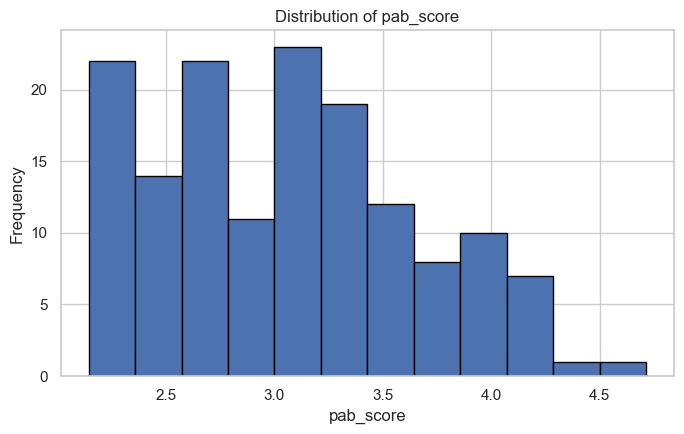

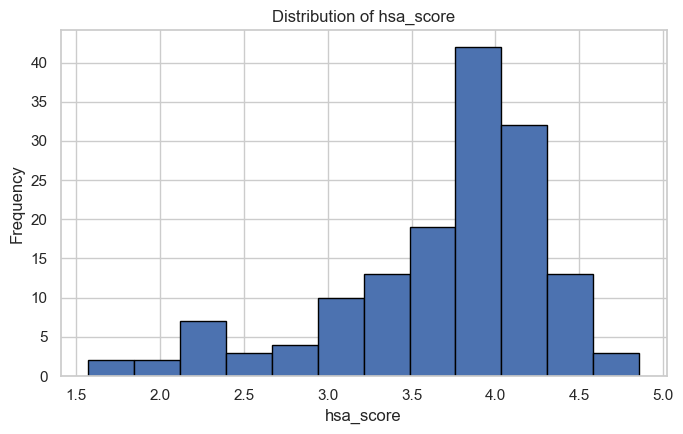

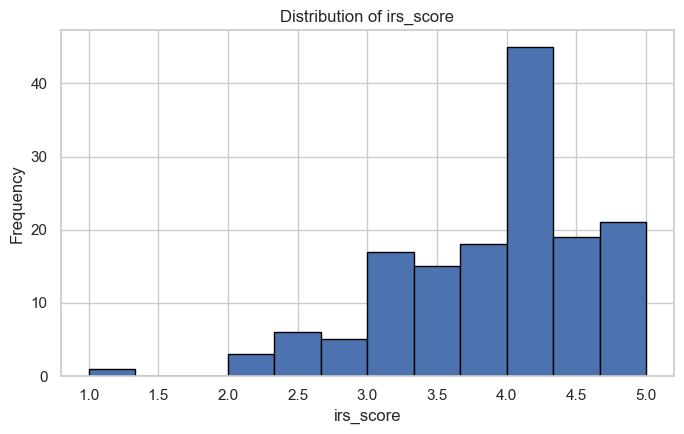

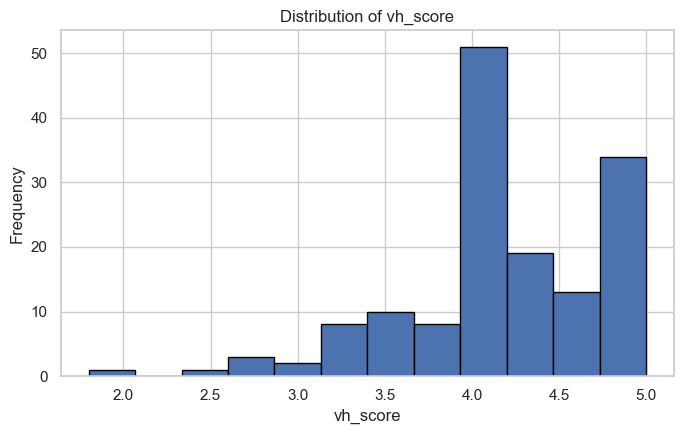

In [31]:
# -------------------------------------------------------------------
# 14. VISUALIZATIONS
# -------------------------------------------------------------------
# A. Histograms for each scale
for col in score_cols:
    plt.figure(figsize=(7, 4.5))
    plt.hist(analysis_df[col].dropna(), bins=12, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / f'{col}_histogram.png', dpi=300)
    plt.show()

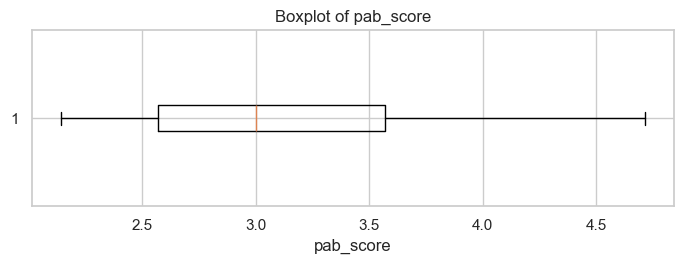

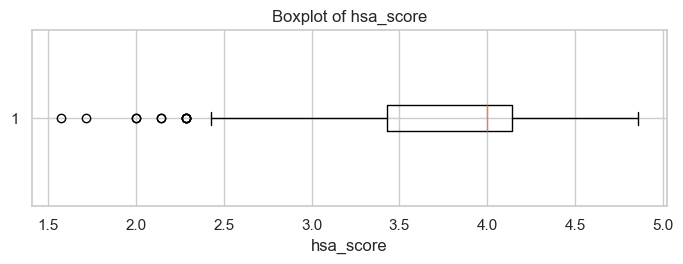

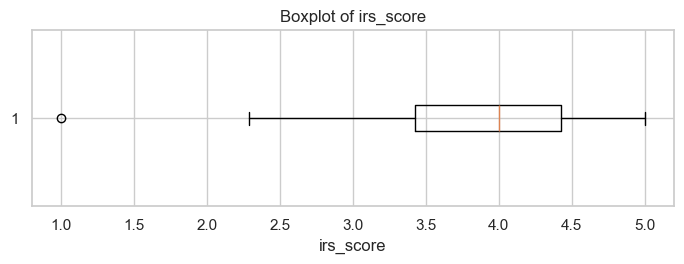

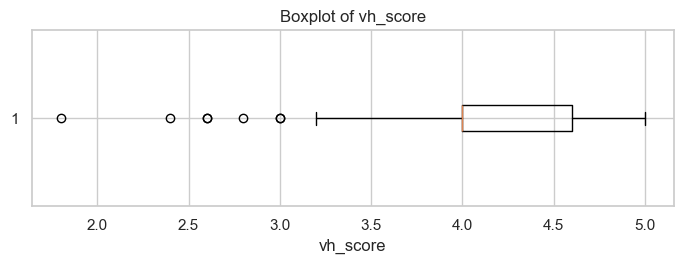

In [32]:
# B. Boxplots for each scale
for col in score_cols:
    plt.figure(figsize=(7, 2.8))
    plt.boxplot(analysis_df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / f'{col}_boxplot.png', dpi=300)
    plt.show()

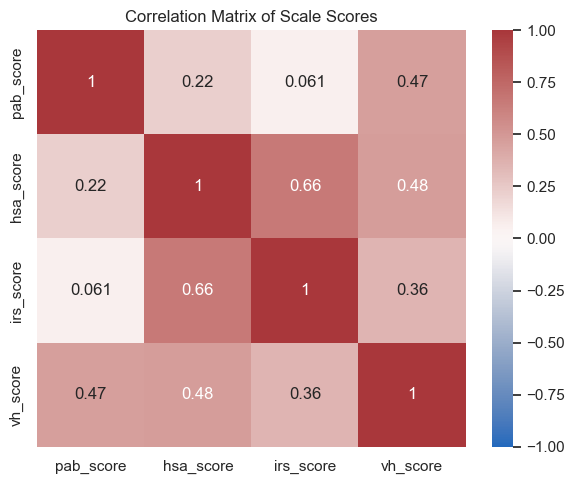

In [33]:
# C. Heatmap of scale correlations
plt.figure(figsize=(6, 5))
sns.heatmap(full_corr, annot=True, cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Scale Scores')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'scale_correlation_heatmap.png', dpi=300)
plt.show()

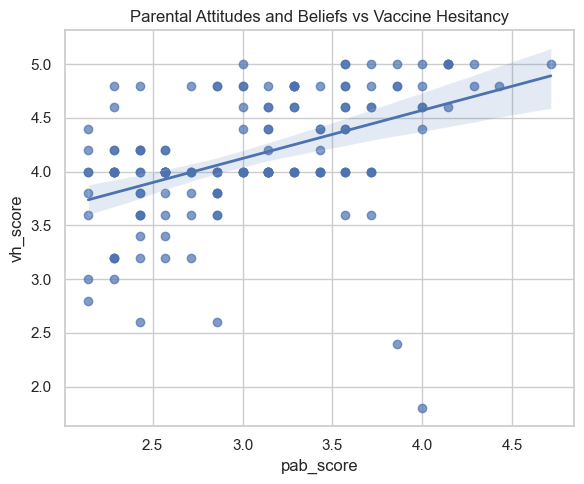

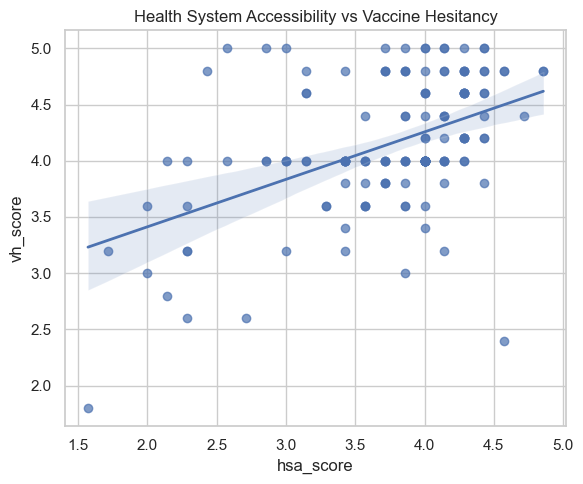

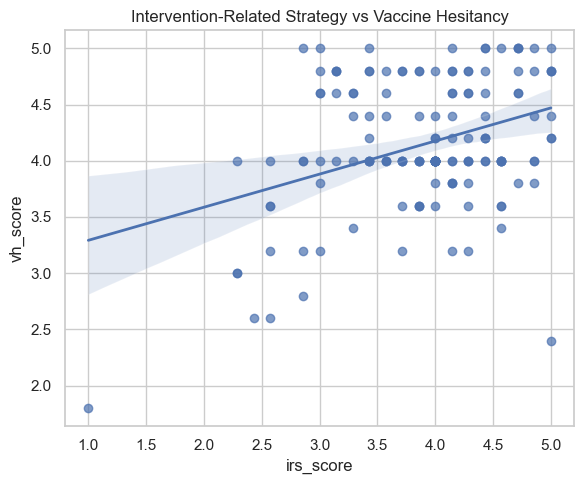

In [34]:
# D. Scatterplots with linear fit for each main hypothesis
for x, y, label in hypothesis_pairs:
    plt.figure(figsize=(6, 5))
    sns.regplot(data=analysis_df, x=x, y=y, scatter_kws={'alpha': 0.7}, line_kws={'linewidth': 2})
    plt.title(label)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    filename = label.lower().replace(' ', '_').replace('/', '_') + '.png'
    plt.savefig(OUTPUT_DIR / 'figures' / filename, dpi=300)
    plt.show()

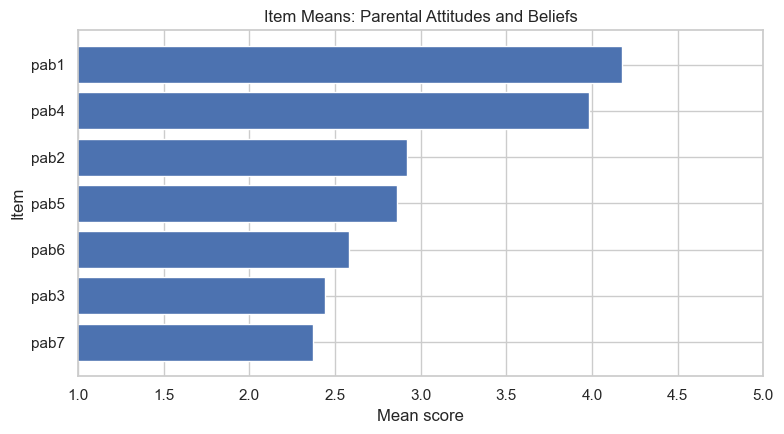

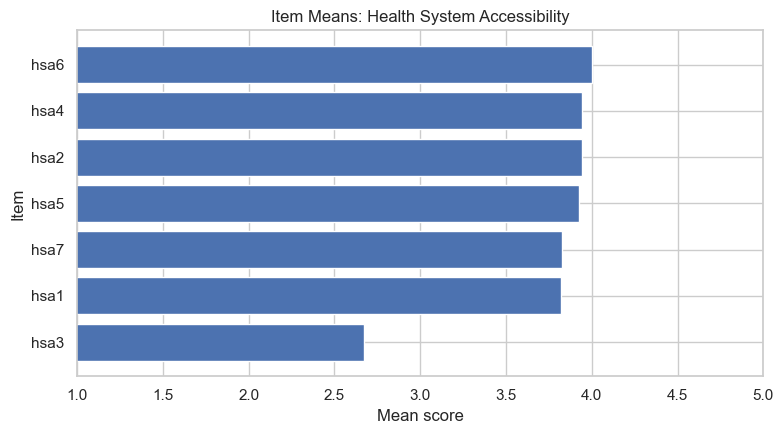

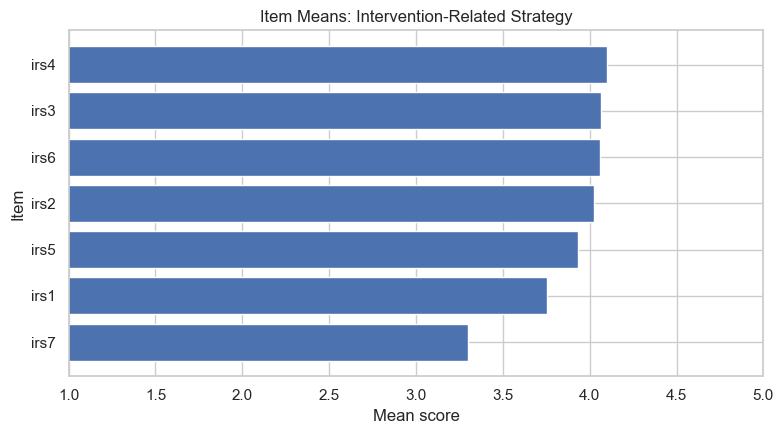

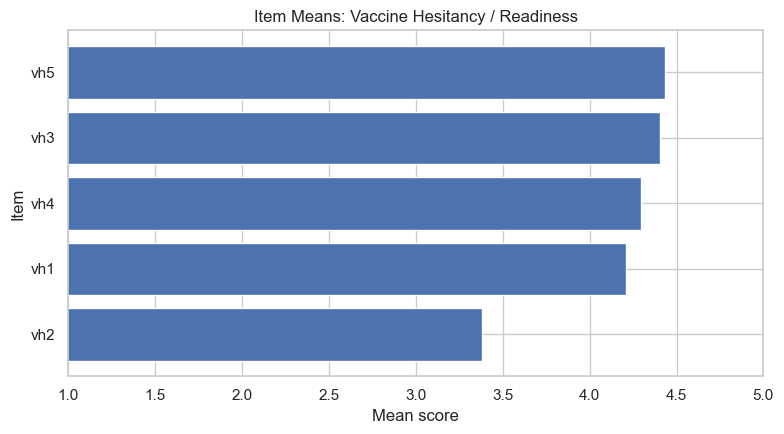

In [35]:
# E. Mean score by item within each section
section_specs = {
    'Parental Attitudes and Beliefs': pab_items,
    'Health System Accessibility': hsa_items,
    'Intervention-Related Strategy': irs_items,
    'Vaccine Hesitancy / Readiness': vh_items
}

for section_name, items in section_specs.items():
    means = analysis_df[items].mean().sort_values()
    plt.figure(figsize=(8, 4.5))
    plt.barh(means.index, means.values)
    plt.xlim(1, 5)
    plt.xlabel('Mean score')
    plt.ylabel('Item')
    plt.title(f'Item Means: {section_name}')
    plt.tight_layout()
    filename = section_name.lower().replace(' ', '_').replace('/', '_') + '_item_means.png'
    plt.savefig(OUTPUT_DIR / 'figures' / filename, dpi=300)
    plt.show()

In [36]:
# -------------------------------------------------------------------
# 15. RESEARCH-READY NARRATIVE OUTPUTS
# -------------------------------------------------------------------
print('DESCRIPTIVE SUMMARY')
display(scale_descriptives)

print('\nRELIABILITY SUMMARY')
display(reliability_table)

print('\nPEARSON CORRELATION SUMMARY')
display(correlation_table)

DESCRIPTIVE SUMMARY


,scale,count,mean,std,min,median,max,skew,interpretation
0,pab_score,150.0,3.046667,0.608684,2.142857,3.0,4.714286,0.373811,Neutral
1,hsa_score,150.0,3.732381,0.658367,1.571429,4.0,4.857143,-1.198479,Agree
2,irs_score,150.0,3.891429,0.710860,1.000000,4.0,5.000000,-0.768176,Agree
3,vh_score,150.0,4.144000,0.583496,1.800000,4.0,5.000000,-0.815012,Agree



RELIABILITY SUMMARY


,scale,n_items,cronbach_alpha,acceptable_ge_0_70
0,Parental Attitudes and Beliefs,7,0.592119,False
1,Health System Accessibility,7,0.747225,True
2,Intervention-Related Strategy,7,0.845416,True
3,Vaccine Hesitancy / Readiness,5,0.644778,False



PEARSON CORRELATION SUMMARY


,comparison,x,y,n,pearson_r,p_value,ci95_low,ci95_high,effect_size,significant_at_0_05
0,Parental Attitudes and Beliefs vs Vaccine Hesi...,pab_score,vh_score,150,0.467945,1.560982e-09,0.332629,0.584382,moderate,True
1,Health System Accessibility vs Vaccine Hesitancy,hsa_score,vh_score,150,0.476359,7.202337e-10,0.342223,0.591467,moderate,True
2,Intervention-Related Strategy vs Vaccine Hesit...,irs_score,vh_score,150,0.358782,6.530926e-06,0.210631,0.490822,moderate,True


In [37]:
# Example APA-style interpretation statements
for _, row in correlation_table.iterrows():
    comp = row['comparison']
    r = row['pearson_r']
    p = row['p_value']
    lo = row['ci95_low']
    hi = row['ci95_high']
    decision = 'reject the null hypothesis' if row['significant_at_0_05'] else 'fail to reject the null hypothesis'
    print(
        f"{comp}: r = {r:.3f}, 95% CI [{lo:.3f}, {hi:.3f}], p = {p:.4g}. "
        f"This indicates a {row['effect_size']} positive relationship; therefore, we {decision}."
    )

Parental Attitudes and Beliefs vs Vaccine Hesitancy: r = 0.468, 95% CI [0.333, 0.584], p = 1.561e-09. This indicates a moderate positive relationship; therefore, we reject the null hypothesis.
Health System Accessibility vs Vaccine Hesitancy: r = 0.476, 95% CI [0.342, 0.591], p = 7.202e-10. This indicates a moderate positive relationship; therefore, we reject the null hypothesis.
Intervention-Related Strategy vs Vaccine Hesitancy: r = 0.359, 95% CI [0.211, 0.491], p = 6.531e-06. This indicates a moderate positive relationship; therefore, we reject the null hypothesis.


## How to write the Results section
Use this structure in your paper:

1. **Data screening and cleaning**
   - Report the raw number of rows in the CSV.
   - State how many valid respondent rows remained after removing blank rows.
   - Mention that reverse coding was applied to the negatively worded items before score computation.

2. **Descriptive statistics**
   - Report the mean and standard deviation for each construct.
   - Discuss which items had the lowest and highest means.

3. **Reliability**
   - Report Cronbach's alpha for each scale.
   - If any scale is below .70, acknowledge it as a limitation and mention item diagnostics.

4. **Inferential statistics**
   - Report Pearson's r, p-value, and 95% confidence interval for each hypothesis.
   - State whether each null hypothesis is rejected or not rejected at α = .05.

5. **Figures**
   - Use the histograms, boxplots, heatmap, and scatterplots to support interpretation.

## If you later want regression
Because the notebook already converts the column names to safe snake_case names, an OLS model would work like this:

```python
import statsmodels.formula.api as smf

model = smf.ols('vh_score ~ pab_score + hsa_score + irs_score', data=analysis_df).fit()
print(model.summary())
```

This avoids the `PatsyError` caused by spaces in names such as `Mean HSA`.

In [38]:
# -------------------------------------------------------------------
# 16. SAVE A CLEANED ANALYSIS DATASET
# -------------------------------------------------------------------
analysis_df.to_csv(OUTPUT_DIR / 'cleaned_analysis_dataset.csv', index=False)
print('All outputs saved to:', OUTPUT_DIR.resolve())

All outputs saved to: /Users/freshliannes.rosal/Documents/Stat Client/Princess /gomez_analysis_outputs


In [3]:
import pandas as pd
import numpy as np
from IPython.display import display

# -----------------------------
# 1. LOAD DATA
# -----------------------------
file_path = "Dataset-Gomez-Et-al.csv"   # Update path if needed
df_raw = pd.read_csv(file_path)

# Study item columns
pab_items = [f"PAB{i}" for i in range(1, 8)]
hsa_items = [f"HSA{i}" for i in range(1, 8)]
irs_items = [f"IRS{i}" for i in range(1, 8)]
vh_items  = [f"VH{i}"  for i in range(1, 6)]

all_items = pab_items + hsa_items + irs_items + vh_items

# Keep only rows with at least one answered item
df = df_raw.dropna(subset=all_items, how="all").copy()

# Convert item responses to numeric
for col in all_items:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# 2. INTERPRETATION FUNCTION
# -----------------------------
def interpret_mean(mean_value):
    if pd.isna(mean_value):
        return ""
    elif 1.00 <= mean_value <= 1.80:
        return "Strongly Disagree"
    elif 1.81 <= mean_value <= 2.60:
        return "Disagree"
    elif 2.61 <= mean_value <= 3.40:
        return "Neutral"
    elif 3.41 <= mean_value <= 4.20:
        return "Agree"
    elif 4.21 <= mean_value <= 5.00:
        return "Strongly Agree"
    else:
        return ""

# -----------------------------
# 3. REVERSE-CODED ITEMS
# -----------------------------
reverse_items = {
    "PAB2", "PAB3", "PAB5", "PAB6", "PAB7",
    "HSA3",
    "VH2"
}

def reverse_score(series):
    return 6 - series

# -----------------------------
# 4. ITEM STATEMENTS
# -----------------------------
constructs = {
    "PAB": {
        "title": "Parental Attitudes and Beliefs",
        "items": {
            "PAB1": "I trust the information I receive about vaccines.",
            "PAB2": "It is better for my child to develop immunity by getting sick than by receiving a vaccine.",
            "PAB3": "Children should receive fewer vaccines at one time.",
            "PAB4": "Children who receive more vaccines are less likely to get sick.",
            "PAB5": "My child might experience serious side effects from a vaccine.",
            "PAB6": "Some childhood vaccines might not be completely safe.",
            "PAB7": "Some vaccines may not effectively prevent certain diseases."
        }
    },
    "HSA": {
        "title": "Health System Accessibility",
        "items": {
            "HSA1": "Health staff is tailored to the number of clients and their needs.",
            "HSA2": "Getting to and from the health center is easy for me.",
            "HSA3": "Cost is a serious barrier to using health care.",
            "HSA4": "The physical space of the health center is suitable for receiving services.",
            "HSA5": "The expected time to receive the services I need is appropriate.",
            "HSA6": "The quality of services provided in the health center is acceptable.",
            "HSA7": "My living conditions are taken into account, such as marital status, ability to pay, and cultural differences."
        }
    },
    "IRS": {
        "title": "Intervention-Related Strategy",
        "items": {
            "IRS1": "I have attended community-based immunization outreach activities in my area.",
            "IRS2": "Outreach programs in my community make it easier for me to access vaccines for my child.",
            "IRS3": "The current strategies used by health authorities are effective in promoting child immunization.",
            "IRS4": "I have seen or heard about vaccination campaigns through TV, radio, or social media.",
            "IRS5": "I feel more confident about vaccines after seeing or hearing health campaign messages.",
            "IRS6": "Health workers or volunteers have visited my home to remind me about my child/ren’s vaccination status.",
            "IRS7": "I regularly receive SMS or phone call reminders for my child/ren’s vaccination schedule."
        }
    },
    "VH": {
        "title": "Vaccine Hesitancy among Mothers with Children under Five Years Old",
        "items": {
            "VH1": "I am convinced the appropriate authorities do only allow effective and safe vaccines.",
            "VH2": "My child/ren sometimes miss out on vaccinations because vaccination is bothersome.",
            "VH3": "I ensure my child/children are vaccinated because protecting them from serious illness is important to me.",
            "VH4": "I make sure my child/children are vaccinated because the risk of them getting infected is too high.",
            "VH5": "I make certain that my child/children receive all the essential vaccinations on time."
        }
    }
}

# -----------------------------
# 5. FUNCTION TO BUILD TABLE
# -----------------------------
def build_variable_table(df, variable_code, variable_info):
    rows = []
    scored_columns = []

    # item-level rows
    for i, (col, statement) in enumerate(variable_info["items"].items(), start=1):
        s = df[col]

        rows.append({
            "No.": i,
            "Statement": statement,
            "M": s.mean(),
            "SD": s.std(ddof=1),
            "Interpretation": interpret_mean(s.mean())
        })

        # for the OVERALL construct score
        if col in reverse_items:
            scored_columns.append(reverse_score(s).rename(col))
        else:
            scored_columns.append(s.rename(col))

    # overall construct score per respondent
    scored_df = pd.concat(scored_columns, axis=1)
    composite_score = scored_df.mean(axis=1, skipna=True)

    rows.append({
        "No.": "",
        "Statement": "Overall",
        "M": composite_score.mean(),
        "SD": composite_score.std(ddof=1),
        "Interpretation": interpret_mean(composite_score.mean())
    })

    table = pd.DataFrame(rows)

    # round values for presentation
    table["M"] = table["M"].round(2)
    table["SD"] = table["SD"].round(2)

    return table

# -----------------------------
# 6. GENERATE TABLES
# -----------------------------
tables = {}

for code, info in constructs.items():
    table = build_variable_table(df, code, info)
    tables[code] = table

    print(f"\n{'='*90}")
    print(f"Table: {info['title']}")
    print(f"{'='*90}")
    display(table)

# -----------------------------
# 7. OPTIONAL: EXPORT TO EXCEL
# One sheet per variable
# -----------------------------
output_excel = "Gomez_Item_Level_Descriptive_Tables_with_Interpretation.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    for code, info in constructs.items():
        tables[code].to_excel(writer, sheet_name=code, index=False)

print(f"\nSaved to: {output_excel}")


Table: Parental Attitudes and Beliefs


,No.,Statement,M,SD,Interpretation
0,1,I trust the information I receive about vaccines.,4.17,0.95,Agree
1,2,It is better for my child to develop immunity ...,3.08,1.42,Neutral
2,3,Children should receive fewer vaccines at one ...,3.56,1.10,Agree
3,4,Children who receive more vaccines are less li...,3.98,1.04,Agree
4,5,My child might experience serious side effects...,3.14,1.16,Neutral
5,6,Some childhood vaccines might not be completel...,3.42,1.17,Agree
6,7,Some vaccines may not effectively prevent cert...,3.63,1.01,Agree
7,,Overall,3.05,0.61,Neutral



Table: Health System Accessibility


,No.,Statement,M,SD,Interpretation
0,1,Health staff is tailored to the number of clie...,3.82,1.02,Agree
1,2,Getting to and from the health center is easy ...,3.94,1.11,Agree
2,3,Cost is a serious barrier to using health care.,3.33,1.33,Neutral
3,4,The physical space of the health center is sui...,3.94,0.94,Agree
4,5,The expected time to receive the services I ne...,3.93,0.88,Agree
5,6,The quality of services provided in the health...,4.00,1.06,Agree
6,7,"My living conditions are taken into account, s...",3.83,0.90,Agree
7,,Overall,3.73,0.66,Agree



Table: Intervention-Related Strategy


,No.,Statement,M,SD,Interpretation
0,1,I have attended community-based immunization o...,3.75,1.10,Agree
1,2,Outreach programs in my community make it easi...,4.03,0.89,Agree
2,3,The current strategies used by health authorit...,4.07,0.83,Agree
3,4,I have seen or heard about vaccination campaig...,4.10,0.75,Agree
4,5,I feel more confident about vaccines after see...,3.93,1.03,Agree
5,6,Health workers or volunteers have visited my h...,4.06,0.94,Agree
6,7,I regularly receive SMS or phone call reminder...,3.30,1.28,Neutral
7,,Overall,3.89,0.71,Agree



Table: Vaccine Hesitancy among Mothers with Children under Five Years Old


,No.,Statement,M,SD,Interpretation
0,1,I am convinced the appropriate authorities do ...,4.21,0.82,
1,2,My child/ren sometimes miss out on vaccination...,2.62,1.35,Neutral
2,3,I ensure my child/children are vaccinated beca...,4.41,0.72,Strongly Agree
3,4,I make sure my child/children are vaccinated b...,4.29,0.76,Strongly Agree
4,5,I make certain that my child/children receive ...,4.43,0.71,Strongly Agree
5,,Overall,4.14,0.58,Agree



Saved to: Gomez_Item_Level_Descriptive_Tables_with_Interpretation.xlsx
